# 🚀 Day 34: Feature Engineering

---

## Objectives

---

- Understand Feature Engineering and its importance in machine learning.
- Extract meaningful features from a real-world business dataset.
- Improve model performance using engineered features.
- Visualize the impact of feature engineering on predictions.

---

### 1. Introduction to Feature Engineering

---

#### 1.1 What is Feature Engineering?

---

Feature Engineering is the process of transforming raw data into useful features that enhance machine learning models. It includes:<br>
✅ Feature Extraction – Creating new features from existing ones.<br>
✅ Feature Transformation – Scaling, encoding, and normalizing features.<br>
✅ Feature Selection – Identifying and keeping the most important features.<br>

---

#### 1.2 Why is Feature Engineering Important?

---

- Improves prediction accuracy.
- Helps models learn better patterns.
- Reduces overfitting by eliminating irrelevant features.

---

### 2. Dataset Overview: Customer Churn Data

---

We will use the Customer Churn Dataset from a telecommunications company. The dataset contains:<br>
📌 Demographic Features: Gender, Senior Citizen, Partner, Dependents<br>
📌 Subscription Details: Contract Type, Monthly Charges, Tenure<br>
📌 Usage Patterns: Streaming TV, Streaming Movies, Internet Service<br>
📌 Target Variable: Churn (Whether the customer left or not)<br>

---

#### 2.1 Load Dataset

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
#Load the dataset
df = pd.read_csv('TelcoCustomerChurn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. EDA

---

In [3]:
#Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

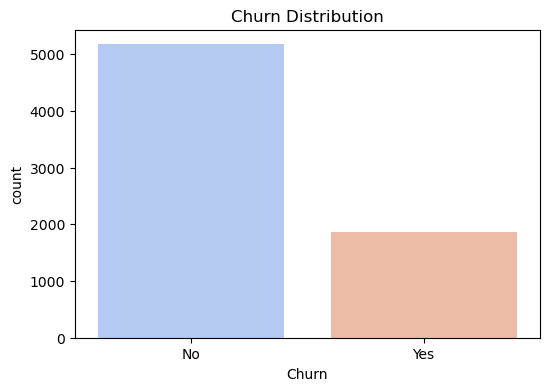

In [8]:
#Visualize Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='coolwarm', legend=False)
plt.title('Churn Distribution')
plt.show()

### 4. Feature Engineering

---

In [9]:
#Handling Misisng Values
df.replace(" ", np.nan, inplace=True)

In [16]:
print(df['TotalCharges'].dtype)

object


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [12]:
#Creating New Features
df['TenureYears'] = df['tenure'] / 12
df['ChargeRatio'] = df['TotalCharges'] / (df['MonthlyCharges'] + 1)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [14]:
#Encoding Categorical Features
df = pd.get_dummies(df, columns=['Contract', 'PaymentMethod', 'InternetService'], drop_first=True)

### 5. Data Preprocessing

---

In [15]:
#Define Features and target variables
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes':1, 'No':0})

In [16]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [18]:
X_train.dtypes

gender                                    object
SeniorCitizen                             object
Partner                                   object
Dependents                                object
tenure                                     int64
PhoneService                              object
MultipleLines                             object
OnlineSecurity                            object
OnlineBackup                              object
DeviceProtection                          object
TechSupport                               object
StreamingTV                               object
StreamingMovies                           object
PaperlessBilling                          object
MonthlyCharges                           float64
TotalCharges                             float64
TenureYears                              float64
ChargeRatio                              float64
Contract_One year                           bool
Contract_Two year                           bool
PaymentMethod_Credit

In [19]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [20]:
#Standardizing numeric Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 6. Model Training and Evaluation 

___

In [21]:
#Train a RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [22]:
#Predictions
y_pred = model.predict(X_test_scaled)

In [24]:
#Model evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1036
           1       0.63      0.46      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.78      1409



### 7. Visualization of Feature Importance

---

In [26]:
print(f'Number of Features in importances: {len(importances)}')
print(f'Number of Features in X.columns: {len(feature_names)}')

Number of Features in importances: 32
Number of Features in X.columns: 25


In [27]:
feature_names = X_train.columns

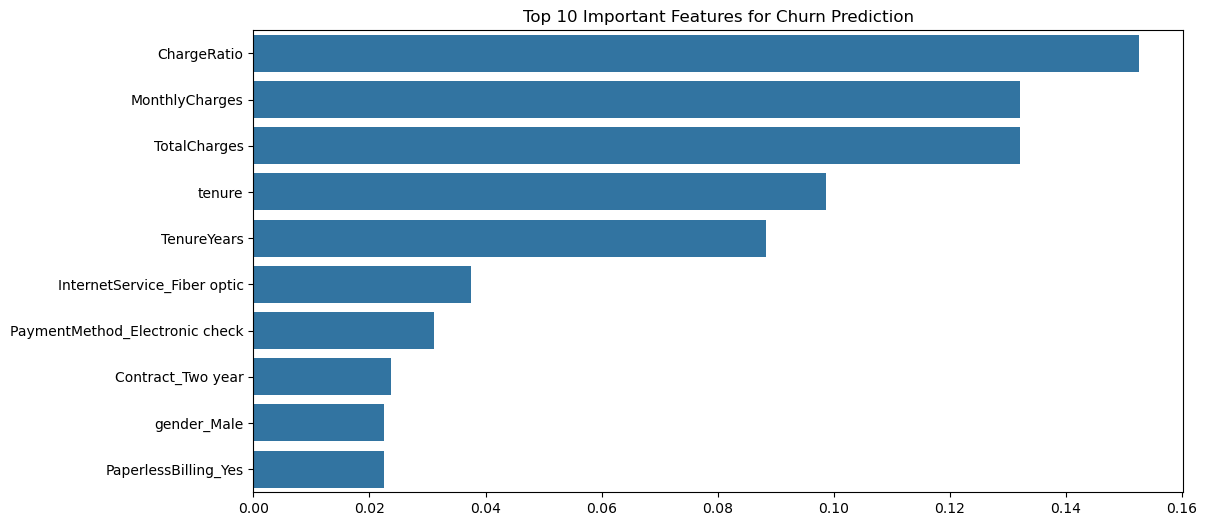

In [28]:
top_n = min(10, len(importances))
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
sns.barplot(x=importances[sorted_indices][:top_n], y=np.array(feature_names)[sorted_indices][:top_n])
plt.title(f'Top {top_n} Important Features for Churn Prediction')
plt.show()